In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

Série chargée : 144 valeurs, premières valeurs :
Month
1949-01-01    112
1949-02-01    118
1949-03-01    132
1949-04-01    129
1949-05-01    121
Name: Passengers, dtype: int64


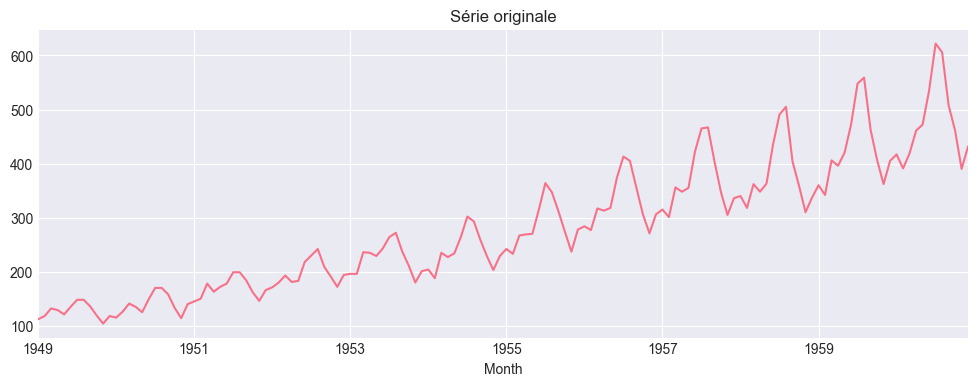

In [9]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url, parse_dates=['Month'], index_col='Month')
serie = df['Passengers'].sort_index()

print(f"Série chargée : {serie.shape[0]} valeurs, premières valeurs :\n{serie.head()}")
serie.plot(title="Série originale", figsize=(12,4))
plt.show()

In [11]:
if serie.std() / serie.mean() > 0.5:
    print("Variance dépend du niveau → application de np.log1p")
    serie_transformed = np.log1p(serie)
else:
    serie_transformed = serie.copy()

In [12]:
def adf_report(series, name=""):
    stat, pvalue, *_ = adfuller(series.dropna())
    print(f"ADF {name}: stat={stat:.3f}, p={pvalue:.3f}")
    return pvalue

pvalue_original = adf_report(serie_transformed, "série transformée")

ADF série transformée: stat=0.815, p=0.992


In [13]:
diff1 = serie_transformed.diff().dropna()
pvalue_diff1 = adf_report(diff1, "diff ordre 1")

if pvalue_diff1 > 0.05:
    print("Série non stationnaire → ARIMA avec d=1")

ADF diff ordre 1: stat=-2.829, p=0.054
Série non stationnaire → ARIMA avec d=1


In [14]:
split_date = "1960-10-01"
train = serie_transformed.loc[:split_date]
test = serie_transformed.loc[split_date:]
print("Train / Test shapes:", train.shape, test.shape)

Train / Test shapes: (142,) (3,)


Baseline persistance — MAE: 56.50, RMSE: 58.33


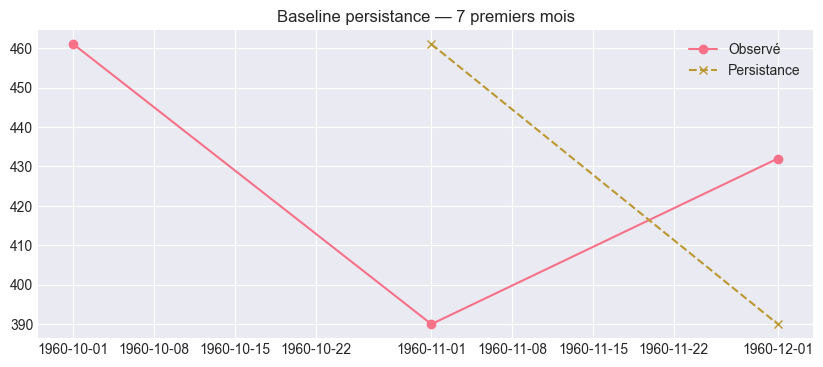

In [16]:
def persistence_forecast(y):
    return y.shift(1)

baseline_pred = persistence_forecast(test).dropna()
baseline_true = test.loc[baseline_pred.index]

mae_base = mean_absolute_error(baseline_true, baseline_pred)
rmse_base = np.sqrt(mean_squared_error(baseline_true, baseline_pred))
print(f"Baseline persistance — MAE: {mae_base:.2f}, RMSE: {rmse_base:.2f}")

plt.figure(figsize=(10,4))
plt.plot(test.iloc[:7], marker='o', label="Observé")
plt.plot(baseline_pred.iloc[:7], marker='x', linestyle='--', label="Persistance")
plt.title("Baseline persistance — 7 premiers mois")
plt.legend()
plt.show()

In [18]:
orders_ar = [6, 12, 24]
results_ar = []

for p in orders_ar:
    model = AutoReg(train, lags=p, old_names=False)
    model_fit = model.fit()
    pred = model_fit.predict(start=test.index[0], end=test.index[-1])
    rmse = np.sqrt(mean_squared_error(test, pred))  # <- correction ici
    results_ar.append((p, model_fit.aic, rmse))

df_ar = pd.DataFrame(results_ar, columns=["p", "AIC", "RMSE"])
print("Résultats AR(p) :\n", df_ar)

best_p = df_ar.loc[df_ar['RMSE'].idxmin(), 'p']
print("Meilleur p choisi :", best_p)

Résultats AR(p) :
     p          AIC       RMSE
0   6  1324.157750  39.130134
1  12  1070.844640  21.464283
2  24   916.479597  14.929260
Meilleur p choisi : 24


C:\Users\DELL\Desktop\TP1_IA_générative\mon_env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\DELL\Desktop\TP1_IA_générative\mon_env\Lib\site-packages\statsmodels\tsa\deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)
C:\Users\DELL\Desktop\TP1_IA_générative\mon_env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\DELL\Desktop\TP1_IA_générative\mon_env\Lib\site-packages\statsmodels\tsa\deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a freq

C:\Users\DELL\Desktop\TP1_IA_générative\mon_env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


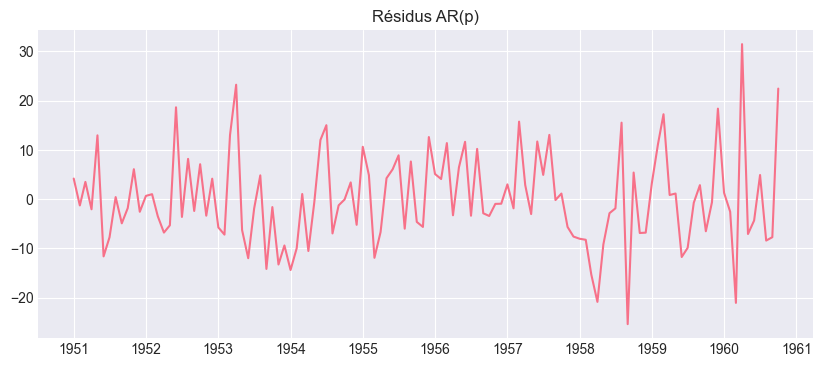

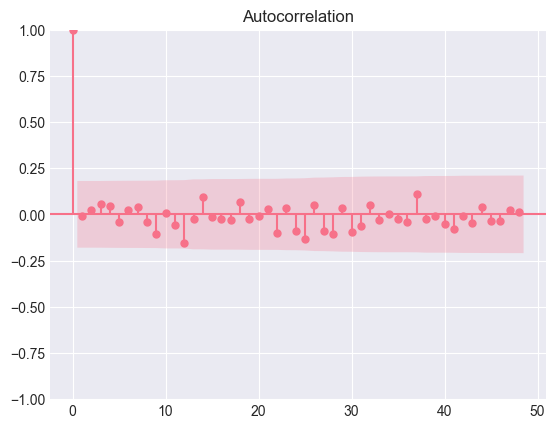

In [19]:
model_ar = AutoReg(train, lags=int(best_p), old_names=False)
model_fit_ar = model_ar.fit()
residuals_ar = model_fit_ar.resid

plt.figure(figsize=(10,4))
plt.plot(residuals_ar)
plt.title("Résidus AR(p)")
plt.show()

plot_acf(residuals_ar, lags=48)
plt.show()


In [23]:
orders_arima = [(2,1,2), (5,1,0), (3,1,3)]
report_arima = []

for order in orders_arima:
    model = ARIMA(train, order=order)
    model_fit = model.fit()
    pred = model_fit.predict(start=test.index[0], end=test.index[-1])
    rmse = np.sqrt(mean_squared_error(test, pred))  # <- correction
    report_arima.append((order, model_fit.aic, rmse))

df_arima = pd.DataFrame(report_arima, columns=["(p,d,q)", "AIC", "RMSE"])
print("Résultats ARIMA :\n", df_arima)

best_order = df_arima.loc[df_arima['RMSE'].idxmin(), '(p,d,q)']
print("Meilleur ordre ARIMA :", best_order)

C:\Users\DELL\Desktop\TP1_IA_générative\mon_env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\DELL\Desktop\TP1_IA_générative\mon_env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\DELL\Desktop\TP1_IA_générative\mon_env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\DELL\Desktop\TP1_IA_générative\mon_env\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\DELL\Desktop\TP1_IA_générative\mon_env\Lib\site-packages

Résultats ARIMA :
      (p,d,q)          AIC       RMSE
0  (2, 1, 2)  1329.880901  29.055689
1  (5, 1, 0)  1366.768692  41.472005
2  (3, 1, 3)  1322.254861  37.383391
Meilleur ordre ARIMA : (2, 1, 2)


C:\Users\DELL\Desktop\TP1_IA_générative\mon_env\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


C:\Users\DELL\Desktop\TP1_IA_générative\mon_env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\DELL\Desktop\TP1_IA_générative\mon_env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\DELL\Desktop\TP1_IA_générative\mon_env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\DELL\Desktop\TP1_IA_générative\mon_env\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


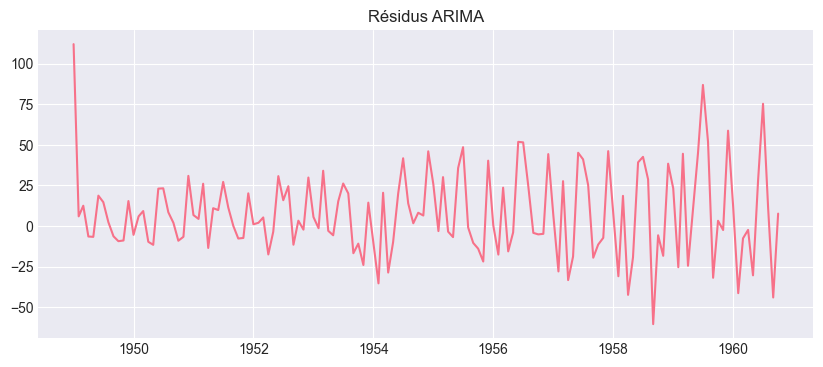

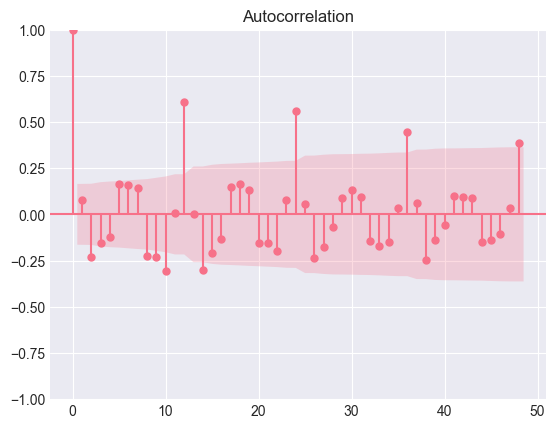

In [24]:
model_arima = ARIMA(train, order=best_order)
model_fit_arima = model_arima.fit()
residuals_arima = model_fit_arima.resid

plt.figure(figsize=(10,4))
plt.plot(residuals_arima)
plt.title("Résidus ARIMA")
plt.show()

plot_acf(residuals_arima, lags=48)
plt.show()

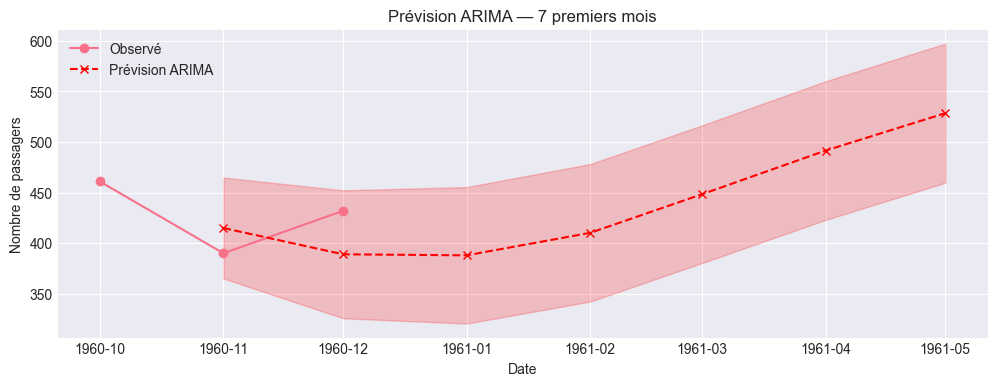

In [25]:
forecast = model_fit_arima.get_forecast(steps=7)
forecast_ci = forecast.conf_int()

plt.figure(figsize=(12,4))
plt.plot(test.iloc[:7], marker='o', label="Observé")
plt.plot(forecast.predicted_mean, marker='x', linestyle='--', label="Prévision ARIMA", color='red')
plt.fill_between(forecast_ci.index,
                 forecast_ci.iloc[:,0],
                 forecast_ci.iloc[:,1],
                 color='red', alpha=0.2)
plt.title("Prévision ARIMA — 7 premiers mois")
plt.xlabel("Date")
plt.ylabel("Nombre de passagers")
plt.legend()
plt.show()

C:\Users\DELL\Desktop\TP1_IA_générative\mon_env\Lib\site-packages\statsmodels\tsa\deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)


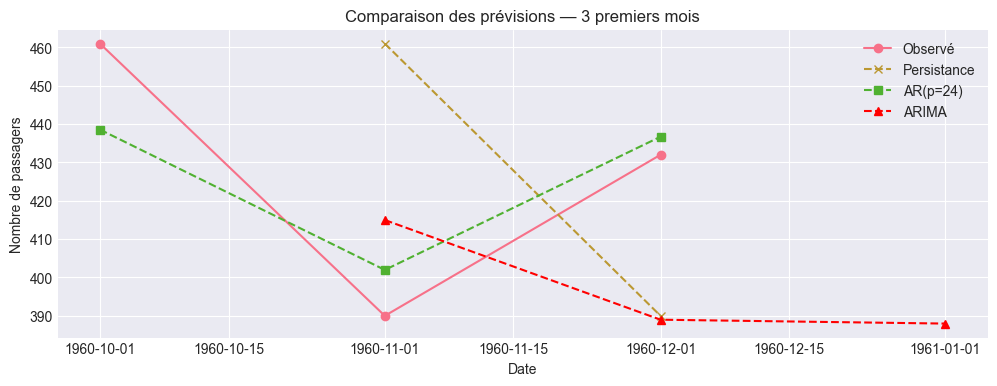

In [27]:
n_points = min(7, len(test))

# Prévision AR(p) sur ces points
pred_ar7 = model_fit_ar.predict(start=test.index[0], end=test.index[n_points-1])

# Même pour le graphique
plt.figure(figsize=(12,4))
plt.plot(test.iloc[:n_points], marker='o', label="Observé")
plt.plot(baseline_pred.iloc[:n_points], marker='x', linestyle='--', label="Persistance")
plt.plot(pred_ar7, marker='s', linestyle='--', label=f"AR(p={best_p})")
plt.plot(forecast.predicted_mean.iloc[:n_points], marker='^', linestyle='--', color='red', label="ARIMA")
plt.title(f"Comparaison des prévisions — {n_points} premiers mois")
plt.xlabel("Date")
plt.ylabel("Nombre de passagers")
plt.legend()
plt.show()

In [28]:
df_compare = pd.DataFrame({
    "Modèle": ["Persistance", f"AR(p={int(best_p)})", f"ARIMA{best_order}"],
    "MAE": [
        mae_base,
        df_ar.loc[df_ar['p']==best_p,'RMSE'].values[0],
        df_arima.loc[df_arima['(p,d,q)']==best_order,'RMSE'].values[0]
    ],
    "RMSE": [
        rmse_base,
        df_ar.loc[df_ar['p']==best_p,'RMSE'].values[0],
        df_arima.loc[df_arima['(p,d,q)']==best_order,'RMSE'].values[0]
    ],
    "AIC": [
        "—",
        df_ar.loc[df_ar['p']==best_p,'AIC'].values[0],
        df_arima.loc[df_arima['(p,d,q)']==best_order,'AIC'].values[0]
    ]
})
print("Comparaison des modèles :\n", df_compare)

Comparaison des modèles :
            Modèle        MAE       RMSE          AIC
0     Persistance  56.500000  58.330952            —
1        AR(p=24)  14.929260  14.929260   916.479597
2  ARIMA(2, 1, 2)  29.055689  29.055689  1329.880901
